# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07fv2_HUA_PREC_NSI
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v2 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab (5 counties): NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (17 counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos 

In [9]:
community_id_by_name = 'Seaside, OR: NSI Building inventory for Clatsop County, OR'

In [10]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Seaside_OR_NSI
Seaside, OR is in OREGON
Focal place: Seaside
Seaside, OR is in Clatsop County, OR with FIPS code 41007
Use IN-CORE: False


## Setup Python Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Fri Mar 07 15:29:25 2025 Central Standard Time

                OS : Windows (10 10.0.22631 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [13]:
basevintage_options = ['2010', '2020']

Generating Housing Unit Inventory v2.0.0 data for Seaside, OR
Clatsop County, OR : county FIPS Code 41007
File already exists, skipping: OutputData/Seaside_OR_NSI/../hui_v2-0-0_Seaside_OR_NSI_2010_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'st

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07a_generate_hui.py:152: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  hui_incore_df_fixed = hui_incore_df.applymap(lambda cell: int(cell) if str(cell).endswith('.0') else cell)


   Download date was ['NSI_2025-03-07']
Generate Address point inventory for: Seaside_OR_NSI
Based on building inventory: NSI
Generate Address point inventory for: Seaside_OR_NSI
Based on building inventory: NSI
***************
Address Point Inventory Workflow
***************

Generating Address Point Inventory v2.0.0 data for Seaside_OR_NSI 2010
***************
Obtaining Census Block, Place, and PUMA Data
***************

File already exists: c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\OutputData/tl_2010_Seaside_OR_NSI_tabblockplacepuma10EPSG4269.csv
Converting blk104269 to Geodataframe
***************
Predicting Housing Unit Estimates
***************

Housing Unit Estimate File already exists: c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\OutputData/huest_v2-0-0_Seaside_OR_NSI_2010_NSI.csv
Clatsop County, OR : county FIPS Code 41007
File already exists on local drive: c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\OutputData/addp

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:472: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_groups[self.new_char] = merged_groups[self.new_char].\


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding Tract2020 expected length 11
Dataframe has required geo levels ['state', 'county', 'tract']
state is type object
county is type object
tract is type object
Confirming Tract2020 has expected length.
Longest Tract2020 : 41007951300
Tract2020 Expected Length 11 Available Length 11
Checking primary key name uniqueidB19001
Primary key variable uniqueidB19001 is unique.
Primary key uniqueidB19001 has no missing values
['uniqueidB19001', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'incomegroup', 'hu_counter', 'family', 'family_flagsetrm', 'family_Tract2020_flagsetrm']
Observations without primary flag set 7836
Observations without geovar flag set 7836
After updated observations without geovar flag set 7836
Setting 0 flags for family set before random merge.
0 observations do not have required variable Tract2020
0 observations do not have required variable race
0 observa

...

....................2432 Buildings have Residential Archetype RES1-1SNB
9476 Buildings have Residential Archetype RES1-1SWB
1218 Buildings have Residential Archetype RES1-2SNB
3359 Buildings have Residential Archetype RES1-2SWB
122 Buildings have Residential Archetype RES1-3SNB
374 Buildings have Residential Archetype RES1-3SWB
0 Buildings have Residential Archetype RES1-SLNB
0 Buildings have Residential Archetype RES1-SLWB
0 Buildings have Residential Archetype RES1
2368 Buildings have Residential Archetype RES2
1027 Buildings have Residential Archetype RES3A
189 Buildings have Residential Archetype RES3B
25 Buildings have Residential Archetype RES3C
11 Buildings have Residential Archetype RES3D
2 Buildings have Residential Archetype RES3E
13 Buildings have Residential Archetype RES3F
298 Buildings have Residential Archetype RES4
7 Buildings have Residential Archetype RES5
14 Buildings have Residential Archetype RES6
83 Buildings have building_area_var less than 300
12 Buildings have 

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07c_generate_addpt.py:800: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  applymap(lambda cell: int(cell) if str(cell).endswith('.0') else cell)


Longest Block ID: 999999999999999
Shortest Block ID: 999999999999999
Not using IN-CORE. Dataset_id is the dataframe
The Address Point Inventory ID contains a pandas dataframe
Housing Unit Allocation for: Seaside_OR_NSI
Based on building inventory: NSI
Running up Housing Unit Allocation for Seaside_OR_NSI

***************************************
    Run Housing Unit Allocation for Seaside_OR_NSI
***************************************


***************************************
    Merge housing unit and address point data with first 3 counters.
***************************************

Round 1

***************************************
***************************************

Performing random merge at geography level: Block

***************************************
***************************************


***************************************
***************************************

Attempt to merge hui on all common group vars.

***************************************
******************

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1

Setting 19150 flags for strctid secondary data not used.
0 observations do not have required variable Block2020
0 observations do not have required variable huicounter3
0 observations do not have required variable ownershp1
Setting 0 flags for observations without required variable Block2020
Setting 0 flags for observations without required variable huicounter3
Setting 0 flags for observations without required variable ownershp1
Attempting random merge for 19150 secondary observations.

***************************************
    Preparing secondary by NA data for random merge.
***************************************

Sorting by  ['addptid']
Sorting before random merge order by ['Block2020', 'huicounter3', 'ownershp1', 'random_order']
Generating random merge order by ['Block2020', 'huicounter3', 'ownershp1']
NA

***************************************
    Random Merge primary with secondary by NA
***************************************

Check merge vars includes geovarid: ['Block2020',

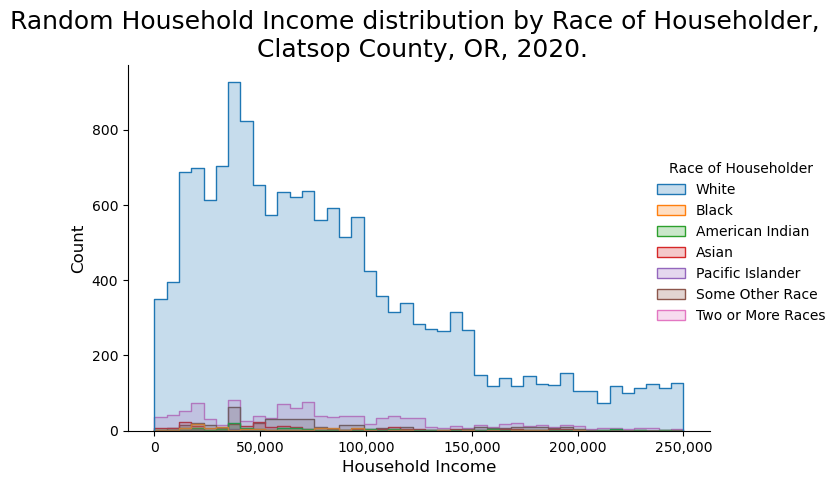

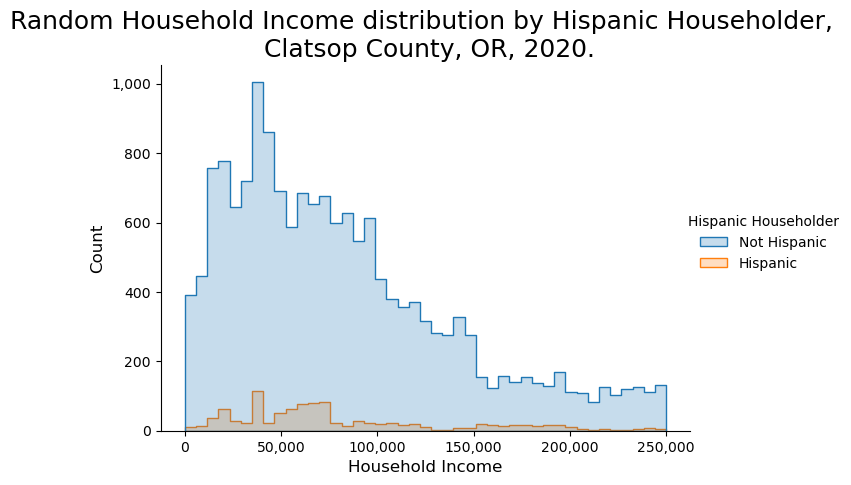

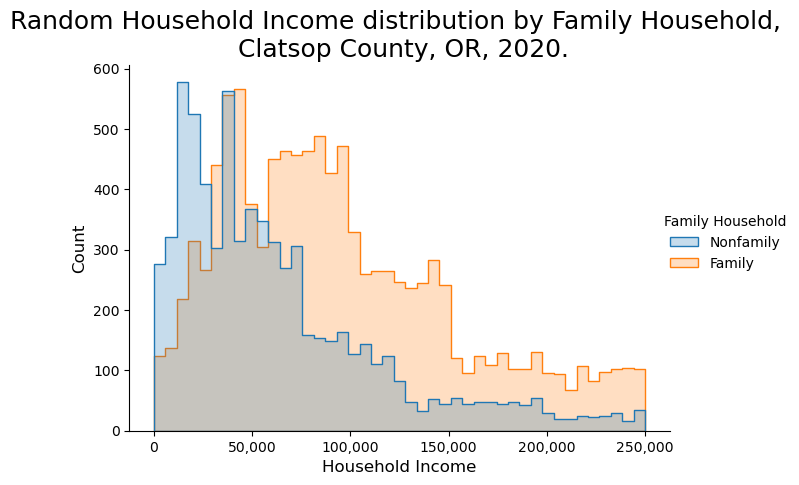

In [14]:
hua_hui_gdf_dict = {}
for basevintage in basevintage_options:
    workflow = process_community_workflow(
                communities,
                seed = 9876,
                version = '2.0.0',
                version_text = 'v2-0-0',
                basevintage = basevintage,
                outputfolder ="OutputData",
                outputfolders = {},
                savefiles = True)
    hua_hui_gdf_dict[basevintage] = workflow.process_communities()

## Run Person Record File

In [ ]:
'''
version = '3.0.0'
version_text = 'v3-0-0'

# open, read, and execute python program with reusable commands
from pyncoda.ncoda_07e_generate_prec import generate_prec_functions

# Save Outputfolder - due to long folder name paths output saved to folder with shorter name
# files from this program will be saved with the program name - 
# this helps to follow the overall workflow
outputfolder = "OutputData"
# Make directory to save output
if not os.path.exists(outputfolder):
    os.mkdir(outputfolder)

# Set random seed for reproducibility
seed = 1000
basevintage = 2020

generate_prec_df = generate_prec_functions(
                    communities =   communities,
                    seed =          seed,
                    version =       version,
                    version_text=   version_text,
                    basevintage=    basevintage,
                    outputfolder=   outputfolder
                    )

prec_df = generate_prec_df.generate_prec_v300()
'''

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [ ]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

In [ ]:
# add race ethnicity to data frame for better map legends
hua_hui_race_gdf = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf)
hua_hui_race_gdf = PopResultsTable.add_hhinc_df(hua_hui_gdf)

# add category for missing building id
bldg_uniqueid = communities[community_id]['building_inventory']['bldg_uniqueid']
# add category for missing building id
buildingdata_conditions = {'cat_var' : {'variable_label' : 'Building Data Availability',
                         'notes' : 'Does Housing Unit have building data?'},
              'condition_list' : {
                1 : {'condition': f"(df['{bldg_uniqueid}'] == 'missing building id')", 'value_label': "0 Missing Building Data"},
                2 : {'condition': f"(df['{bldg_uniqueid}'] != 'missing building id')", 'value_label': "1 Building Data Available"}}
            }
hua_hui_gdf = add_label_cat_conditions_df(hua_hui_gdf, conditions = buildingdata_conditions)

In [ ]:
hua_hui_gdf.head()

In [ ]:
# set dataframe for focal place
yr = str(basevintage)[2:4]
focalplace_hua_hui_gdf =  hua_hui_gdf.loc[hua_hui_gdf[f'placeNAME{yr}'] == focalplace].copy(deep=True)

In [ ]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = str(basevintage),
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

In [ ]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = str(basevintage),
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

In [ ]:
'''
PopResultsTable.pop_results_table(
                  input_df = prec_df, 
                  who = "Total Population by Persons", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = str(basevintage),
                  row_index = "Race",
                  col_index = 'Hispanic')
'''

In [ ]:
PopResultsTable.pop_results_table(hua_hui_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = str(basevintage),
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

In [ ]:
try:
    print("Attempting to generate the population results table...")
    table1 = PopResultsTable.pop_results_table(
        focalplace_hua_hui_gdf,
        who="Total Population by Households",
        what="by Tenure",
        where=focalplace,
        when=str(basevintage),
        row_index="Tenure Status",
        col_index="Building Data Availability_str",
        row_percent="0 Missing Building Data"
    )
    print("Population results table generated successfully.")
except Exception as e:
    table1 = "no table generated"
    print(f"No Missing Building Data: {e}")

table1

In [ ]:
PopResultsTable.pop_results_table(hua_hui_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = str(basevintage),
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

In [ ]:
PopResultsTable.pop_results_table(focalplace_hua_hui_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = str(basevintage),
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

In [ ]:
hua_hui_gdf['All'] = 'All'

PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf, 
                  who = "Total Population by Households", 
                  what = "by Group Quarters Type",
                  where = countyname,
                  when =str(basevintage),
                  row_index = 'Group Quarters Type',
                  col_index = 'All')

In [ ]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf, 
                  who = "Total Households", 
                  what = "by Vacancy Type",
                  where = countyname,
                  when = str(basevintage),
                  row_index = 'Vacancy Type',
                  col_index = 'All')

#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [ ]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Maps

In [ ]:
basevintage

In [ ]:
#mapname = 'hhincdotmap'
mapname = f'hhracedotmap_{basevintage}'
# Map column
#map_var = 'Household Income Group'
map_var = 'Race Ethnicity'
place = focalplace

yr = str(basevintage)[2:4]
condition1 = "(hua_hui_race_gdf.race >= 1)"
condition2 = f"(hua_hui_race_gdf.placeNAME{yr} == '{place}')"
conditions = f"{condition1} & {condition2}"

county_hua_gdf = hua_hui_race_gdf.loc[eval(condition1)].copy(deep=True)
county_hua_gdf = county_hua_gdf.to_crs(epsg=4326)
focal_place_hua_gdf = hua_hui_race_gdf.loc[eval(conditions)].copy(deep=True)
focal_place_hua_gdf = focal_place_hua_gdf.to_crs(epsg=4326)

In [ ]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

bldg_inv_id = communities[community_id]['building_inventory']['id']
outputfolder = 'OutputData'
community = communities[community_id]['community_name']

county_map = plot_dotmap_map(gdf=county_hua_gdf,
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = community,
                        year = basevintage,
                        outputfolder=outputfolder,
                        condition_id = "1",
                        basemap_source = cx.providers.CartoDB.Positron)

In [ ]:
# get xlim and ylim for focal place
xlim = [focal_place_hua_gdf.total_bounds[0], focal_place_hua_gdf.total_bounds[2]]
ylim = [focal_place_hua_gdf.total_bounds[1], focal_place_hua_gdf.total_bounds[3]]
print(xlim, ylim)

In [ ]:

focal_place_map = plot_dotmap_map(gdf=county_hua_gdf,
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = basevintage,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf)

In [ ]:
Image(focal_place_map+'.png', width= 800, height=800)

### Explore by Income

In [ ]:
mapname = f'hhincdotmap_{basevintage}'

# Map column
map_var = 'Household Income Group'

# Ensure 'hhinc' is numeric
hua_hui_race_gdf['hhinc'] = pd.to_numeric(hua_hui_race_gdf['hhinc'], errors='coerce')

condition1 = "(hua_hui_race_gdf.hhinc >= 1)"

county_hua_gdf = hua_hui_race_gdf.loc[eval(condition1)].copy(deep=True)
county_hua_gdf = county_hua_gdf.to_crs(epsg=4326)

In [ ]:
# get xlim and ylim for focal place
xlim = [focal_place_hua_gdf.total_bounds[0], focal_place_hua_gdf.total_bounds[2]]
ylim = [focal_place_hua_gdf.total_bounds[1], focal_place_hua_gdf.total_bounds[3]]

focal_place_map = plot_dotmap_map(gdf=county_hua_gdf,
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = basevintage,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf)

In [ ]:
focal_place_map

In [ ]:
Image(focal_place_map+'.png', width= 800, height=800)

## View Codebook
The Housing Unit Allocation methodology generates a codebook for the housing unit inventory.

Look in the OutputData folder to find the codebook.